<a href="https://colab.research.google.com/github/blackfloyd/behaviour-analysis-using-handwriting-sampling/blob/main/griffith.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# coding: utf-8

# ============================================================
# TRAINING SCRIPT : CNN + BiLSTM (CRNN)
# ============================================================

import os
import cv2
import pickle
import math
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    BatchNormalization, Reshape,
    Bidirectional, LSTM
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Reload variables
import importlib
import variables as vars
importlib.reload(vars)

# -------------------- PARAMETERS --------------------
img_rows, img_cols = vars.img_rows, vars.img_cols
batch_size = vars.batch_size
epochs = vars.epochs

model_json_path = vars.model_json_path
model_path = vars.model_path
prediction_file_dir_path = vars.prediction_file_dir_path
label_obj_path = vars.label_obj_path

DATASET_PATH = "/content/drive/MyDrive/FEATURE-BASED-IMAGES/"

# -------------------- LOAD DATA --------------------
data = []
labels = []

print("📂 Loading images...")

for folder, subfolders, files in os.walk(DATASET_PATH):
    for name in files:
        if name.lower().endswith(".jpg"):

            img_path = os.path.join(folder, name)

            # read grayscale
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            # resize
            img = cv2.resize(img, (img_cols, img_rows))

            # ---- THRESHOLDING (ROBUST) ----
            img = cv2.adaptiveThreshold(
                img,
                255,
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY,
                11,
                2
            )

            # morphology
            kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
            img = cv2.dilate(~img, kernel, iterations=1)
            img = ~img

            # expand dims
            img = np.expand_dims(img, axis=-1)

            data.append(img)
            labels.append(os.path.basename(folder))

data = np.array(data, dtype="float32")
labels = np.array(labels)

print("✅ Total samples:", len(data))

# -------------------- NUM CLASSES --------------------
num_classes = len(np.unique(labels))
print(f"🎯 Detected {num_classes} unique classes.")

# -------------------- SPLIT --------------------
x_train, x_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# -------------------- LABEL ENCODING --------------------
lb = LabelEncoder()

y_train = lb.fit_transform(y_train)
y_test = lb.transform(y_test)

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# -------------------- DATA AUGMENTATION --------------------
print("🔄 Setting up data augmentation...")

data_augmentor = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    fill_mode="nearest",
    rescale=1.0 / 255
)

val_data_augmentor = ImageDataGenerator(rescale=1.0 / 255)

data_augmentor.fit(x_train)

train_generator = data_augmentor.flow(
    x_train,
    y_train,
    batch_size=batch_size,
    seed=42
)

validation_generator = val_data_augmentor.flow(
    x_test,
    y_test,
    batch_size=batch_size,
    seed=42
)

print("✅ Data augmentation ready.")

# ============================================================
# MODEL : CNN + BiLSTM
# ============================================================

input_shape = (img_rows, img_cols, 1)

model = Sequential()

# ---------------- CNN ----------------

# Block 1
model.add(Conv2D(32, (3, 3), padding="same",
                 activation="relu",
                 input_shape=input_shape))
model.add(BatchNormalization())
model.add(Conv2D(32, (3, 3), padding="same", activation="relu"))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.30))

# Block 3
model.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.35))

# ---------------- CNN → SEQUENCE ----------------
model.add(
    Reshape(
        (img_cols // 8,
         (img_rows // 8) * 128)
    )
)

# ---------------- BiLSTM ----------------
model.add(Bidirectional(LSTM(128, return_sequences=False)))
model.add(Dropout(0.5))

# ---------------- CLASSIFIER ----------------
model.add(Dense(256, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(num_classes, activation="softmax"))

# ---------------- COMPILE ----------------
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================================
# CALLBACKS
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.3)
]

# ============================================================
# TRAIN
# ============================================================

steps_per_epoch = math.ceil(len(x_train) / batch_size)
validation_steps = math.ceil(len(x_test) / batch_size)

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# EVALUATE
# ============================================================

score = model.evaluate(
    validation_generator,
    verbose=0,
    steps=validation_steps
)

print("📊 Test loss:", score[0])
print("📊 Test accuracy:", score[1])

# ============================================================
# SAVE MODEL
# ============================================================

with open(model_json_path, "w") as json_file:
    json_file.write(model.to_json())

model.save_weights(model_path)

with open(label_obj_path, "wb") as lb_file:
    pickle.dump(lb, lb_file)

print("✅ Model + LabelEncoder saved successfully!")
print("🗂️ Class mapping:",
      dict(zip(lb.classes_, lb.transform(lb.classes_))))

📂 Loading images...
✅ Total samples: 16
🎯 Detected 4 unique classes.
🔄 Setting up data augmentation...
✅ Data augmentation ready.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 4096)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │     4,326,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,533,988 (17.30 MB)

 Trainable params: 4,533,028 (17.29 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.2500 - loss: 2.6702 - val_accuracy: 0.2500 - val_loss: 1.3887 - learning_rate: 3.0000e-04
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.4167 - loss: 1.8683 - val_accuracy: 0.2500 - val_loss: 1.3869 - learning_rate: 3.0000e-04
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.0833 - loss: 2.6872 - val_accuracy: 0.2500 - val_loss: 1.3871 - learning_rate: 3.0000e-04
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.4167 - loss: 1.5352 - val_accuracy: 0.2500 - val_loss: 1.3873 - learning_rate: 3.0000e-04
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.3333 - loss: 1.6013 - val_accuracy: 0.0000e+00 - val_loss: 1.3878 - learning_rate: 3.0000e-04
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.2500 - loss: 1.9890 - val_accuracy: 0.2500 - val_loss: 1.3908 - learning_rate: 3.0000e-04
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.6667 - loss: 1.0659 

In [ ]:
import os

# Create a directory for variables if it doesn't exist (optional, if you want it in a subdir)
# os.makedirs('config', exist_ok=True)

# Define the content for variables.py
variables_content = """
# variables.py

# Image dimensions
img_rows = 256
img_cols = 256

# Training parameters
batch_size = 32
num_classes = 4 # This has been updated to 4 based on the dataset
epochs = 50

# Model and output paths
model_json_path = "model.json"
model_path = "model.weights.h5" # Corrected filename extension
prediction_file_dir_path = "/content/drive/MyDrive/Prediction/" # Updated to user-provided path
label_obj_path = "label_encoder.pkl"
"""

# Write the content to variables.py
with open("variables.py", "w") as f:
    f.write(variables_content)

print("Updated variables.py with the user-provided prediction folder path.")
print("Please review and modify variables.py if necessary, especially 'num_classes'.")

Updated variables.py with the user-provided prediction folder path.
Please review and modify variables.py if necessary, especially 'num_classes'.


📊 Generating predictions for confusion matrix...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step

🧾 Classification Report:

              precision    recall  f1-score   support

     CLASS_0       0.25      1.00      0.40         1
     CLASS_1       0.00      0.00      0.00         1
     CLASS_2       0.00      0.00      0.00         1
     CLASS_3       0.00      0.00      0.00         1

    accuracy                           0.25         4
   macro avg       0.06      0.25      0.10         4
weighted avg       0.06      0.25      0.10         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


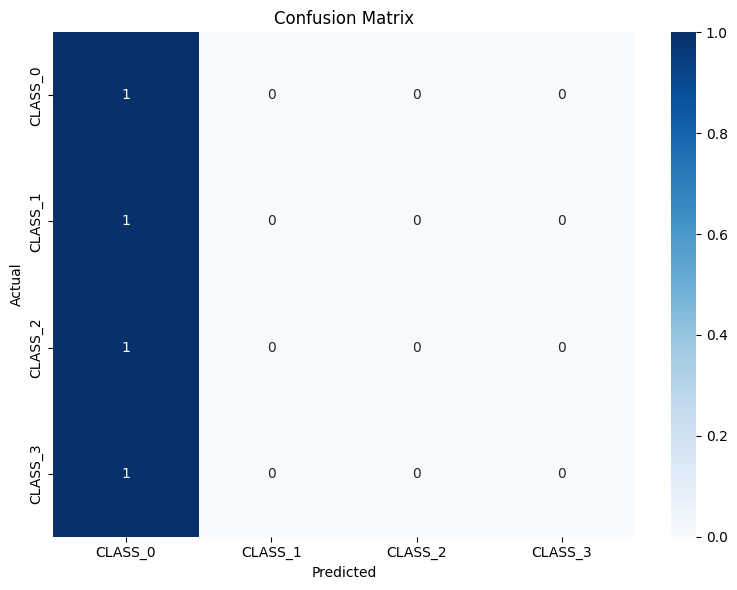

✅ Confusion matrix saved as confusion_matrix.png


In [ ]:
# ============================================================
# CONFUSION MATRIX + CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Generating predictions for confusion matrix...")

# Predict probabilities
y_pred_probs = model.predict(validation_generator, steps=validation_steps)

# Convert to class indices
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test[:len(y_pred)], axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("\n🧾 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=lb.classes_))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=lb.classes_,
    yticklabels=lb.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

print("✅ Confusion matrix saved as confusion_matrix.png")


In [ ]:
!pip install tensorflow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install opencv-python

Processing image: /content/drive/MyDrive/FEATURE-BASED-IMAGES/CLASS_0/img1.jpg


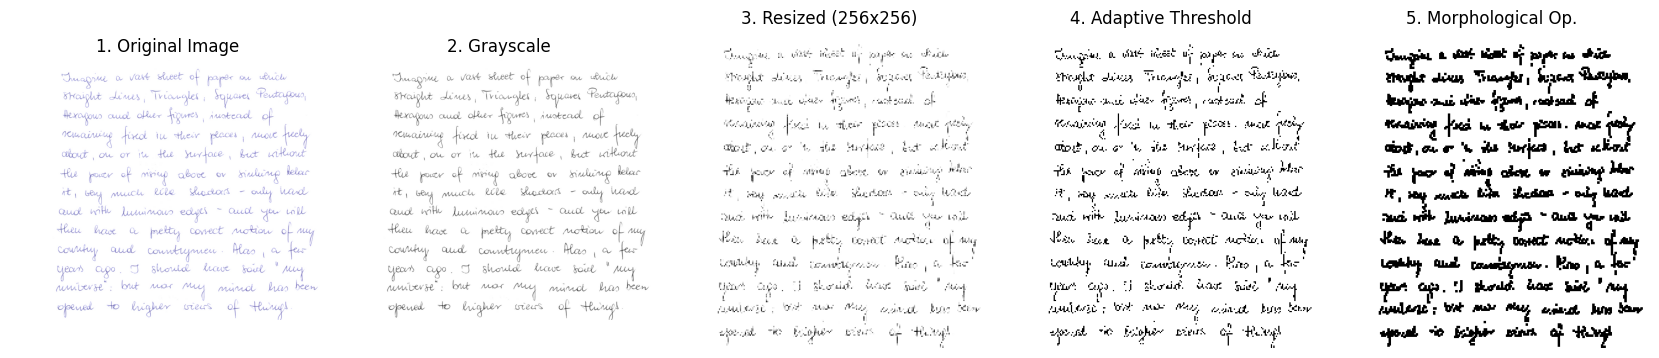

✅ Image preprocessing visualization updated for review.
Carefully review the resized and adaptively thresholded images. Adjust 'img_rows', 'img_cols', 'blockSize', and 'C' in the code if needed.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import variables as vars # Import variables for img_rows and img_cols

# Reload the variables module to ensure changes are picked up
import importlib
importlib.reload(vars)

# -------------------- PARAMETERS --------------------
img_rows, img_cols = vars.img_rows, vars.img_cols

# 1. Select a sample image path
# This path should point to an actual image in your Google Drive setup.
# Adjust if your CLASS_0/img1.jpg is not available or if you prefer another image.
img_path = '/content/drive/MyDrive/FEATURE-BASED-IMAGES/CLASS_0/img1.jpg'

print(f"Processing image: {img_path}")

# Create a figure to display the images
plt.figure(figsize=(20, 5)) # Increased figure size for better visibility

# Original image (for display reference)
original_img = cv2.imread(img_path)
if original_img is None:
    print(f"❌ Error: Image not found at {img_path}. Please check the path and if Google Drive is mounted.")
else:
    # Convert BGR to RGB for matplotlib display
    original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 6, 1)
    plt.imshow(original_rgb)
    plt.title('1. Original Image')
    plt.axis('off')

    # 2. Load the image in grayscale
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    plt.subplot(1, 6, 2)
    plt.imshow(img_gray, cmap='gray')
    plt.title('2. Grayscale')
    plt.axis('off')

    # 3. Resize the grayscale image
    img_resized = cv2.resize(img_gray, (img_cols, img_rows)) # Use updated img_cols, img_rows
    plt.subplot(1, 6, 3)
    plt.imshow(img_resized, cmap='gray')
    plt.title(f'3. Resized ({img_cols}x{img_rows})')
    plt.axis('off')

    # 4. Apply adaptive thresholding
    # Parameters: src, maxValue, adaptiveMethod, thresholdType, blockSize, C
    # ADAPTIVE_THRESH_GAUSSIAN_C: weighted mean of neighborhood
    # THRESH_BINARY: values above threshold are maxValue, others are 0
    # blockSize: Size of a pixel neighborhood that is used to calculate a threshold value. It must be an odd integer.
    # C: A constant subtracted from the mean or weighted mean.
    img_adaptive_thresh = cv2.adaptiveThreshold(
        img_resized, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2 # Example values, can be tuned: blockSize=11, C=2
    )
    plt.subplot(1, 6, 4)
    plt.imshow(img_adaptive_thresh, cmap='gray')
    plt.title('4. Adaptive Threshold')
    plt.axis('off')

    # 5. Apply morphological operations (dilate and invert)
    # First, invert the thresholded image as dilate works on white foreground
    img_inverted_for_morph = ~img_adaptive_thresh # Use adaptive thresholded image
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    img_dilated = cv2.dilate(img_inverted_for_morph, kernel, iterations=1)
    # Invert back to get black foreground on white background
    img_morphed = ~img_dilated

    plt.subplot(1, 6, 5)
    plt.imshow(img_morphed, cmap='gray')
    plt.title('5. Morphological Op.')
    plt.axis('off')

    # For comparison, visualize original fixed threshold if desired
    # _, img_fixed_thresh = cv2.threshold(img_resized, 220, 255, cv2.THRESH_BINARY)
    # plt.subplot(1, 6, 6)
    # plt.imshow(img_fixed_thresh, cmap='gray')
    # plt.title('6. Fixed Threshold (old)')
    # plt.axis('off')

    plt.tight_layout()
    plt.show()

print("✅ Image preprocessing visualization updated for review.")
print("Carefully review the resized and adaptively thresholded images. Adjust 'img_rows', 'img_cols', 'blockSize', and 'C' in the code if needed.")

In [ ]:
# ============================================================
# PREDICTION SCRIPT - TF 2.x COMPATIBLE
# ============================================================

import os
import cv2
import pickle
import numpy as np

from tensorflow.keras.models import model_from_json

# Reload variables to ensure latest paths and dimensions are used
import importlib
import variables as vars
importlib.reload(vars)

# ---------------- PARAMETERS ----------------
img_rows, img_cols = vars.img_rows, vars.img_cols
model_json_path = vars.model_json_path
model_path = vars.model_path
prediction_file_dir_path = vars.prediction_file_dir_path
label_obj_path = vars.label_obj_path

# ============================================================
# PRINT RESULTS
# ============================================================

def print_results(class_lbl, out):
    print("\n" + "~" * 60)

    # Map dataset labels to descriptive labels for printing behaviors
    # ASSUMPTION: This mapping assumes the order of lb.classes_ aligns as follows:
    # CLASS_0 -> LEFT_MARG, CLASS_1 -> RIGHT_MARG, CLASS_2 -> SLANT_ASC, CLASS_3 -> SLANT_DESC
    label_map = {
        'CLASS_0': 'LEFT_MARG',
        'CLASS_1': 'RIGHT_MARG',
        'CLASS_2': 'SLANT_ASC',
        'CLASS_3': 'SLANT_DESC'
    }

    print("Predicted probabilities and associated behaviors:")
    for k, actual_lbl in enumerate(class_lbl):
        descriptive_lbl = label_map.get(actual_lbl, actual_lbl) # Use descriptive label if mapped, else original

        if descriptive_lbl == "LEFT_MARG":
            print(f"\n > {actual_lbl} (LEFT_MARG):")
            print(f"    - Courageous:\t\t\t {round(out[k] * 100, 2)} %")
            # Assuming 'Insecure' is the inverse of 'Courageous' for this class
            print(f"    - Insecure & devotes oneself completely:\t {round(100 - (out[k] * 100), 2)} %")

        elif descriptive_lbl == "RIGHT_MARG":
            print(f"\n > {actual_lbl} (Avoids future & reserved):\t {round(out[k] * 100, 2)} %")

        elif descriptive_lbl == "SLANT_ASC":
            print(f"\n > {actual_lbl} (Optimistic):\t\t\t {round(out[k] * 100, 2)} %")

        elif descriptive_lbl == "SLANT_DESC":
            print(f"\n > {actual_lbl} (Pessimistic):\t\t\t {round(out[k] * 100, 2)} %")
        else:
            # Fallback for unmapped labels
            print(f"\n > {actual_lbl}:\t\t\t {round(out[k] * 100, 2)} %")

    print("~" * 60 + "\n")


# ============================================================
# LOAD MODEL
# ============================================================

def load_trained_model():

    with open(model_json_path, "r") as f:
        model_json = f.read()

    model = model_from_json(model_json)
    model.load_weights(model_path)

    print("✅ Loaded model from disk")

    return model


# ============================================================
# IMAGE PREPROCESSING (UPDATED with adaptive thresholding)
# ============================================================

def preprocess_image(img_path):

    # read grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError("❌ Image not found:" + img_path)

    # resize
    img = cv2.resize(img, (img_cols, img_rows))

    # adaptive thresholding
    img = cv2.adaptiveThreshold(
        img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2 # Using the recommended parameters
    )

    # morphology
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    img = cv2.dilate(~img, kernel, iterations=1)
    img = ~img

    # normalize
    img = img.astype("float32") / 255.0

    # expand dims: (1, H, W, 1)
    img = np.expand_dims(img, axis=-1)
    img = np.expand_dims(img, axis=0)

    return img


# ============================================================
# PREDICT
# ============================================================

def predict_personalities(filename, model_obj, lb_obj):

    img_path = os.path.join(prediction_file_dir_path, filename)

    x = preprocess_image(img_path)

    out = model_obj.predict(x)[0]

    print_results(lb_obj.classes_, out)

    pred_class = lb_obj.inverse_transform([np.argmax(out)])[0]

    return "\n> Prediction Completed! Predicted Class = " + pred_class


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    files = []

    # List only image files in the prediction directory
    if os.path.exists(prediction_file_dir_path):
        for f in os.listdir(prediction_file_dir_path):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                files.append(f)
    files.sort() # Sort files to ensure consistent order

    if files:
        print(f"Found {len(files)} image(s) in the prediction folder. Predicting for all images...")

        # Load model and label encoder once
        model = load_trained_model()
        with open(label_obj_path, "rb") as lb_file:
            lb = pickle.load(lb_file)

        for file_name in files:
            print(f"\n--- Processing image: {file_name} ---")
            res = predict_personalities(file_name, model, lb)
            print(res)

    else:
        print("❌ No image files found for prediction folder! Please ensure `variables.py` points to the correct directory and it contains image files.")

Found 11 image(s) in the prediction folder. Predicting for all images...
✅ Loaded model from disk

--- Processing image: WhatsApp Image 2026-02-01 at 23.39.45.jpeg ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Predicted probabilities and associated behaviors:

 > CLASS_0 (LEFT_MARG):
    - Courageous:			 25.579999923706055 %
    - Insecure & devotes oneself completely:	 74.41999816894531 %

 > CLASS_1 (Avoids future & reserved):	 25.18000030517578 %

 > CLASS_2 (Optimistic):			 23.729999542236328 %

 > CLASS_3 (Pessimistic):			 25.510000228881836 %
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


> Prediction Completed! Predicted Class = CLASS_0

--- Processing image: WhatsApp Image 2026-02-01 at 23.39.46.jpeg ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Predicted probabilities and associated behaviors:

 > CLASS_0 (LEFT_MARG):
    - Courageous:			 26.0 %
